<a href="https://colab.research.google.com/github/TheVailen/frameworks-lab2-time-series/blob/main/lab2_weather_timeseries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Лабораторная работа 2
## Что было обнаружено в исходном файле

При первичном просмотре файла `have_fun.xlsx` обнаружились реальные проблемы исходных данных:

- в таблице 8 листов, но содержательных листов с рядами ровно 3
- два рабочих листа скрыты
- названия листов и городов частично испорчены битой кодировкой
- есть опечатки в названиях городов
- на одном листе есть лишние пустые столбцы
- присутствуют строковые маркеры пропусков: `NAN`, `---`, `?`, `нет данных`;
- часть числовых столбцов смешана с текстовыми категориями:
  - `жарко / нормально / холодно`
  - `сухо / морось / ливень`
  - `солнечно / пасмурно / дождь / снег`
  - `тихо / ветрено / шторм / туман / гроза`
- присутствуют выбросы, например:
  - температура около **79°C**



In [2]:
!pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.9 MB/s eta 0:00:00


In [10]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl

from scipy import stats
from scipy.signal import periodogram

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error

import optuna

In [4]:
RANDOM_STATE = 42


HORIZON = 24 * 7
WINDOW = 24 * 7
ORIGIN_STRIDE = 24
N_TRIALS = 12
N_JOBS_RF = -1

TARGET_COL = "temperature_2m"
TIME_COL = "ds"
CITY_COL = "city"

BASE_NUM_COLS = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "rain",
    "snowfall",
    "weathercode",
    "wind_speed_10m",
    "surface_pressure",
]

## 1. Получаем доступ ко всем листам Excel, включая скрытые





In [11]:
def fix_encoding(text):
    if isinstance(text, str):
        try:
            return text.encode("latin1").decode("cp1251")
        except Exception:
            return text
    return text

wb = openpyxl.load_workbook(XLSX_PATH, data_only=False)

sheet_meta = []
for ws in wb.worksheets:
    sheet_meta.append({
        "sheet_name_raw": ws.title,
        "sheet_name_decoded": fix_encoding(ws.title),
        "state": ws.sheet_state,
        "max_row": ws.max_row,
        "max_col": ws.max_column,
    })

sheet_meta_df = pd.DataFrame(sheet_meta)
sheet_meta_df

,sheet_name_raw,sheet_name_decoded,state,max_row,max_col
0,Ëèñò1,Лист1,visible,125125,10
1,Лист1,Лист1,visible,1,1
2,ÌÀÈ,МАИ,visible,1,1
3,ýòî,это,visible,1,1
4,ÿ,я,visible,1,1
5,!,!,visible,1,1
6,Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû,Лист2_строковые_NaN_выбросы,hidden,125170,25
7,Ëèñò3_ñìåøàííûå_òèïû,Лист3_смешанные_типы,hidden,122737,10


## Показываем все листы и выделяем те, где реально есть данные

In [6]:

display(sheet_meta_df)

data_like_sheets = sheet_meta_df.query("max_row > 10").copy()
display(data_like_sheets)

,sheet_name_raw,sheet_name_decoded,state,max_row,max_col
0,Ëèñò1,Лист1,visible,125125,10
1,Лист1,Лист1,visible,1,1
2,ÌÀÈ,МАИ,visible,1,1
3,ýòî,это,visible,1,1
4,ÿ,я,visible,1,1
5,!,!,visible,1,1
6,Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû,Лист2_строковые_NaN_выбросы,hidden,125170,25
7,Ëèñò3_ñìåøàííûå_òèïû,Лист3_смешанные_типы,hidden,122737,10


,sheet_name_raw,sheet_name_decoded,state,max_row,max_col
0,Ëèñò1,Лист1,visible,125125,10
6,Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû,Лист2_строковые_NaN_выбросы,hidden,125170,25
7,Ëèñò3_ñìåøàííûå_òèïû,Лист3_смешанные_типы,hidden,122737,10


## Ожидаемо: рабочих листов с данными должно оказаться ровно 3

In [12]:
assert len(data_like_sheets) == 3, f"Ожидалось 3 рабочих листа, найдено {len(data_like_sheets)}"
print("Найдено 3 рабочих листа.")

Найдено 3 рабочих листа.


## 2. Загружаем только 3 рабочих листа

In [9]:
data_sheet_names = data_like_sheets["sheet_name_raw"].tolist()

raw_sheets = {}
for s in data_sheet_names:
    df = pd.read_excel(XLSX_PATH, sheet_name=s, engine="openpyxl")
    raw_sheets[s] = df

for s, df in raw_sheets.items():
    print("=" * 100)
    print("RAW SHEET:", s, "->", fix_encdoing(s))
    print("shape:", df.shape)
    display(df.head(3))

RAW SHEET: Ëèñò1 -> Лист1
shape: (125124, 10)


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city
0,3.8,82,0.0,0.0,0.0,3,19.1,1010.000000,2020-01-31 02:00:00,Ãåëåíäæèê
1,-3.0,70,0.0,0.0,0.0,3,24.0,981.900024,2025-02-28 09:00:00,Áëàãîâåùåíñê
2,-1.3,86,0.0,0.0,0.0,2,8.8,1021.200012,2022-01-03 02:00:00,Ãåëåíäæèê


RAW SHEET: Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû -> Лист2_строковые_NaN_выбросы
shape: (125169, 25)


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city,...,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24
0,-6.5,92.0,0,0.0,0.0,3.0,10.8,1000.500000,2019-01-01 00:00:00,Ìîñêâà,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-6.8,92.0,0,0.0,0.0,3.0,10.5,1000.299988,2019-01-01 01:00:00,Ìîñêâà,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-6.8,92.0,0,0.0,0.0,3.0,10.8,1000.000000,2019-01-01 02:00:00,Ìîñêâà,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


RAW SHEET: Ëèñò3_ñìåøàííûå_òèïû -> Лист3_смешанные_типы
shape: (122736, 10)


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city
0,-1.8,85.0,0,0.0,0.0,3,23.5,1015.200012,2019-01-01 00:00:00,Ñàíêò-Ïåòåðáóðã
1,-1.9,83.0,0,0.0,0.0,3,26,1013.200012,2019-01-01 01:00:00,Ñàíêò-Ïåòåðáóðã
2,-2,85.0,0,0.0,0.0,3,26.200001,1011.700012,2019-01-01 02:00:00,Ñàíêò-Ïåòåðáóðã


## 3. Проблемы по каждому листу

In [14]:
def quick_sheet_audit(df, sheet_name):
    out = {}

    out["sheet_name_raw"] = sheet_name
    out["sheet_name_decoded"] = fix_encoding(sheet_name)
    out["rows"] = len(df)
    out["cols"] = len(df.columns)

    unnamed_cols = [c for c in df.columns if str(c).startswith("Unnamed")]
    out["unnamed_cols_count"] = len(unnamed_cols)
    out["all_null_unnamed_cols"] = sum(df[c].isna().all() for c in unnamed_cols)

    if TIME_COL in df.columns:
        out["ds_na"] = int(df[TIME_COL].isna().sum())
        out["time_min"] = df[TIME_COL].min()
        out["time_max"] = df[TIME_COL].max()
        out["sorted_by_time"] = bool(df[TIME_COL].is_monotonic_increasing)
    else:
        out["ds_na"] = None
        out["time_min"] = None
        out["time_max"] = None
        out["sorted_by_time"] = None

    if CITY_COL in df.columns:
        city_decoded = df[CITY_COL].map(fix_encoding)
        out["unique_city_labels_raw"] = int(city_decoded.nunique(dropna=True))
        out["city_value_counts_top10"] = city_decoded.value_counts(dropna=False).head(10).to_dict()
    else:
        out["unique_city_labels_raw"] = None
        out["city_value_counts_top10"] = None

    non_numeric_info = {}
    for col in df.columns:
        if col in [TIME_COL, CITY_COL]:
            continue
        ser = df[col]
        if ser.dtype == "O":
            text_values = ser.dropna().astype(str)
            bad = text_values[pd.to_numeric(text_values, errors="coerce").isna()]
            if len(bad) > 0:
                non_numeric_info[col] = {
                    "bad_count": int(len(bad)),
                    "examples": [fix_encoding(x) for x in bad.head(10).tolist()]
                }
    out["object_non_numeric"] = non_numeric_info

    return out

audit_rows = [quick_sheet_audit(df, s) for s, df in raw_sheets.items()]
audit_df = pd.DataFrame(audit_rows)
display(audit_df[[
    "sheet_name_decoded", "rows", "cols", "unnamed_cols_count", "all_null_unnamed_cols",
    "ds_na", "time_min", "time_max", "sorted_by_time", "unique_city_labels_raw"
]])

,sheet_name_decoded,rows,cols,unnamed_cols_count,all_null_unnamed_cols,ds_na,time_min,time_max,sorted_by_time,unique_city_labels_raw
0,Лист1,125124,10,0,0,0,2019-01-01,2025-12-31 23:00:00,False,10
1,Лист2_строковые_NaN_выбросы,125169,25,15,1,2486,2019-01-01,2025-12-31 23:00:00,False,3
2,Лист3_смешанные_типы,122736,10,0,0,0,2019-01-01,2025-12-31 23:00:00,False,5


In [15]:
# Подробнее
for row in audit_rows:
    print("=" * 120)
    print("Лист:", row["sheet_name_decoded"])
    print("Top city labels:", row["city_value_counts_top10"])
    print("Нечисловые значения в числовых столбцах:")
    for col, info in row["object_non_numeric"].items():
        print(f"  - {col}: {info['bad_count']} шт.; примеры = {info['examples']}")

Лист: Лист1
Top city labels: {'Благовещенск': 61659, 'Геленджик': 61587, 'Геленджикк': 248, 'БЛАГОВЕЩЕНСК': 245, 'Геленджи': 242, 'благовещенск': 239, 'Благовещенскк': 230, 'геленджик': 228, 'Благовещенс': 226, 'ГЕЛЕНДЖИК': 220}
Нечисловые значения в числовых столбцах:
Лист: Лист2_строковые_NaN_выбросы
Top city labels: {'Москва': 61364, 'Находка': 61317, nan: 2487, 'Мосва': 1}
Нечисловые значения в числовых столбцах:
  - temperature_2m: 538 шт.; примеры = ['нет данных', 'нет данных', 'NAN', 'нет данных', '---', 'NAN', 'NAN', '---', '---', 'NAN']
  - precipitation: 537 шт.; примеры = ['---', 'нет данных', 'нет данных', '?', 'нет данных', 'NAN', '---', 'NAN', '?', 'нет данных']
  - wind_speed_10m: 260 шт.; примеры = ['?', '---', '?', '---', 'NAN', 'нет данных', '?', 'нет данных', 'NAN', '---']
  - Unnamed: 11: 1 шт.; примеры = ['temperature_2m']
  - Unnamed: 12: 1 шт.; примеры = ['relative_humidity_2m']
  - Unnamed: 13: 1 шт.; примеры = ['precipitation']
  - Unnamed: 14: 1 шт.; примеры =

### Ключевые выводы

- **Лист1**  
  - перемешан по времени;
  - битая кириллица в `city`;
  - много опечаток в названиях двух городов;
  - есть дубли по времени после нормализации названий;
  - часть числовых значений отсутствует.

- **Лист2 - строковые NaN выбросы**  
  - скрытый лист;
  - есть лишние пустые столбцы;
  - есть пустые строки;
  - строковые обозначения пропусков (`NAN`, `---`, `?`, `нет данных`);
  - выраженные выбросы в температуре и давлении;
  - пропуски времени для одного из городов.

- **Лист3 - смешанные типы**  
  - скрытый лист;
  - смешанные типы в нескольких столбцах;
  - текстовые погодные категории вместо чисел;
  - опечатки в городе `Сочи`;
  - временной индекс полный, но значения требуют унификации.

## 4. Очистка и унификация данных

In [17]:
import re

# Нормализация города
def standardize_city(x):
    x = fix_encoding(x) if isinstance(x, str) else x
    if pd.isna(x):
        return np.nan

    xx = x.strip().lower()

    mapping = {
        "геленджик": "Геленджик",
        "геленджикк": "Геленджик",
        "геленджи": "Геленджик",
        "геленджик ": "Геленджик",
        "геленджик.": "Геленджик",
        "геленджик,": "Геленджик",
        "геленджик-": "Геленджик",
        "геленджик_": "Геленджик",
        "геленджик\n": "Геленджик",
        "геленджик\r\n": "Геленджик",
        "геленджик\t": "Геленджик",
        "геленджиккк": "Геленджик",
        "геленджикь": "Геленджик",
        "геленджикг": "Геленджик",
        "геленджикж": "Геленджик",
        "геленджикй": "Геленджик",
        "геленджикя": "Геленджик",
        "геленджикю": "Геленджик",
        "геленджикъ": "Геленджик",
        "геленджикы": "Геленджик",
        "геленджикэ": "Геленджик",
        "геленджикьь": "Геленджик",

        "благовещенск": "Благовещенск",
        "благовещенскк": "Благовещенск",
        "благовещенс": "Благовещенск",

        "москва": "Москва",
        "мосва": "Москва",

        "находка": "Находка",

        "санкт-петербург": "Санкт-Петербург",

        "сочи": "Сочи",
        "сычи": "Сочи",
        "счи": "Сочи",
        "соч": "Сочи",
    }

    if xx in mapping:
        return mapping[xx]

    xx2 = re.sub(r"[^а-яa-z\- ]", "", xx)
    if xx2 in mapping:
        return mapping[xx2]

    return x.strip().title()


MISSING_MARKERS = {
    "nan", "NAN", "---", "?", "нет данных", "нет", "none", "null", ""
}

WEATHERCODE_TEXT_MAP = {
    "солнечно": 0.0,
    "пасмурно": 3.0,
    "дождь": 61.0,
    "снег": 71.0,
}

TEMP_TEXT_MAP = {
    "холодно": np.nan,
    "нормально": np.nan,
    "жарко": np.nan,
}

PRECIP_TEXT_MAP = {
    "сухо": 0.0,
    "морось": np.nan,
    "ливень": np.nan,
}

WIND_TEXT_MAP = {
    "тихо": np.nan,
    "ветрено": np.nan,
    "шторм": np.nan,
    "туман": np.nan,
    "гроза": np.nan,
}


def normalize_scalar_value(x, column=None):
    if pd.isna(x):
        return np.nan

    if isinstance(x, str):
        x0 = fix_encoding(x).strip()

        if x0 in MISSING_MARKERS or x0.lower() in {m.lower() for m in MISSING_MARKERS}:
            return np.nan

        if column == "weathercode" and x0.lower() in WEATHERCODE_TEXT_MAP:
            return WEATHERCODE_TEXT_MAP[x0.lower()]

        if column == "temperature_2m" and x0.lower() in TEMP_TEXT_MAP:
            return TEMP_TEXT_MAP[x0.lower()]

        if column == "precipitation" and x0.lower() in PRECIP_TEXT_MAP:
            return PRECIP_TEXT_MAP[x0.lower()]

        if column == "wind_speed_10m" and x0.lower() in WIND_TEXT_MAP:
            return WIND_TEXT_MAP[x0.lower()]

        x1 = x0.replace(",", ".")
        try:
            return float(x1)
        except Exception:
            return np.nan

    return x

In [18]:
def read_and_standardize_sheet(sheet_name, df):
    df = df.copy()

    # 1) убрать полностью пустые столбцы
    keep_cols = [c for c in df.columns if not df[c].isna().all()]
    df = df[keep_cols].copy()

    # 2) привести city
    df[CITY_COL] = df[CITY_COL].map(standardize_city)

    # 3) привести смешанные типы к числам
    for col in [c for c in BASE_NUM_COLS if c in df.columns]:
        df[col] = df[col].apply(lambda x: normalize_scalar_value(x, column=col))
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # 4) удалить строки, где нет времени или города
    df = df.dropna(subset=[TIME_COL, CITY_COL]).copy()

    # 5) убрать точные / эквивалентные дубли по (город, время)
    agg_map = {c: "mean" for c in BASE_NUM_COLS if c in df.columns}
    df = (
        df.groupby([CITY_COL, TIME_COL], as_index=False)
          .agg(agg_map)
    )

    # 6) сортировка по времени внутри города
    df = df.sort_values([CITY_COL, TIME_COL]).reset_index(drop=True)

    return df

cleaned_parts = []
for sheet_name, df in raw_sheets.items():
    part = read_and_standardize_sheet(sheet_name, df)
    part["source_sheet"] = fix_encoding(sheet_name)
    cleaned_parts.append(part)

df_all = pd.concat(cleaned_parts, ignore_index=True)
df_all = df_all.sort_values([CITY_COL, TIME_COL]).reset_index(drop=True)

print(df_all.shape)
display(df_all.head())
display(df_all.tail())

(368090, 11)


,city,ds,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,source_sheet
0,Благовещенск,2019-01-01 00:00:00,-13.7,56.0,0.0,0.0,0.0,3.0,12.600000,1008.700012,Лист1
1,Благовещенск,2019-01-01 01:00:00,-13.2,56.0,0.0,0.0,0.0,3.0,16.299999,1008.500000,Лист1
2,Благовещенск,2019-01-01 02:00:00,-12.5,56.0,0.0,0.0,0.0,3.0,18.000000,1008.299988,Лист1
3,Благовещенск,2019-01-01 03:00:00,-12.1,56.0,0.0,0.0,0.0,3.0,18.100000,1007.900024,Лист1
4,Благовещенск,2019-01-01 04:00:00,-11.9,56.0,0.0,0.0,0.0,3.0,17.600000,1007.500000,Лист1


,city,ds,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,source_sheet
368085,Сочи,2025-12-31 19:00:00,2.5,84.0,0.3,0.2,0.07,71.0,5.5,1005.099976,Лист3_смешанные_типы
368086,Сочи,2025-12-31 20:00:00,2.6,79.0,0.1,0.1,0.00,51.0,8.4,1006.099976,Лист3_смешанные_типы
368087,Сочи,2025-12-31 21:00:00,2.2,79.0,0.2,0.1,0.07,71.0,5.3,1006.099976,Лист3_смешанные_типы
368088,Сочи,2025-12-31 22:00:00,1.4,81.0,0.0,0.0,0.00,3.0,4.9,1007.099976,Лист3_смешанные_типы
368089,Сочи,2025-12-31 23:00:00,1.5,75.0,0.0,0.0,0.00,3.0,6.7,1008.099976,Лист3_смешанные_типы


### Проверка состава городов после нормализации

In [19]:
city_counts = (
    df_all.groupby(CITY_COL)
          .agg(
              rows=(TIME_COL, "size"),
              time_min=(TIME_COL, "min"),
              time_max=(TIME_COL, "max")
          )
          .sort_index()
)
display(city_counts)

,rows,time_min,time_max
city,,,
Благовещенск,61336,2019-01-01,2025-12-31 23:00:00
Геленджик,61337,2019-01-01,2025-12-31 23:00:00
Москва,61364,2019-01-01,2025-12-31 23:00:00
Находка,61317,2019-01-01,2025-12-31 02:00:00
Санкт-Петербург,61368,2019-01-01,2025-12-31 23:00:00
Сочи,61368,2019-01-01,2025-12-31 23:00:00


In [21]:
print("Города:", sorted(df_all[CITY_COL].unique()))

Города: ['Благовещенск', 'Геленджик', 'Москва', 'Находка', 'Санкт-Петербург', 'Сочи']


## 5. Приведение к единому временному индексу

In [22]:
global_start = df_all[TIME_COL].min()
global_end = df_all[TIME_COL].max()
full_hourly_index = pd.date_range(global_start, global_end, freq="h")

print("Период:", global_start, "->", global_end)
print("Часов в полном индексе:", len(full_hourly_index))

Период: 2019-01-01 00:00:00 -> 2025-12-31 23:00:00
Часов в полном индексе: 61368


In [23]:
cities = sorted(df_all[CITY_COL].unique())

panel_parts = []
for city in cities:
    city_df = df_all[df_all[CITY_COL] == city].copy().set_index(TIME_COL).sort_index()
    city_df = city_df.reindex(full_hourly_index)
    city_df.index.name = TIME_COL
    city_df[CITY_COL] = city
    panel_parts.append(city_df.reset_index())

panel = pd.concat(panel_parts, ignore_index=True)
panel = panel.sort_values([CITY_COL, TIME_COL]).reset_index(drop=True)

print(panel.shape)
display(panel.head())

(368208, 11)


,ds,city,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,source_sheet
0,2019-01-01 00:00:00,Благовещенск,-13.7,56.0,0.0,0.0,0.0,3.0,12.600000,1008.700012,Лист1
1,2019-01-01 01:00:00,Благовещенск,-13.2,56.0,0.0,0.0,0.0,3.0,16.299999,1008.500000,Лист1
2,2019-01-01 02:00:00,Благовещенск,-12.5,56.0,0.0,0.0,0.0,3.0,18.000000,1008.299988,Лист1
3,2019-01-01 03:00:00,Благовещенск,-12.1,56.0,0.0,0.0,0.0,3.0,18.100000,1007.900024,Лист1
4,2019-01-01 04:00:00,Благовещенск,-11.9,56.0,0.0,0.0,0.0,3.0,17.600000,1007.500000,Лист1


## Сколько пропусков по времени появилось после reindex

In [24]:
missing_summary = (
    panel.groupby(CITY_COL)
         .apply(lambda g: g[BASE_NUM_COLS].isna().all(axis=1).sum())
         .rename("full_missing_rows_after_reindex")
         .reset_index()
)
display(missing_summary)

,city,full_missing_rows_after_reindex
0,Благовещенск,32
1,Геленджик,31
2,Москва,4
3,Находка,51
4,Санкт-Петербург,0
5,Сочи,0


## 6. Обработка пропусков и выбросов

## Физически разумные диапазоны для контроля качества
## Значения вне диапазона считаем выбросами -> NaN -> затем интерполяция

In [26]:
PHYSICAL_BOUNDS = {
    "temperature_2m": (-60, 60),
    "relative_humidity_2m": (0, 100),
    "precipitation": (0, 500),
    "rain": (0, 500),
    "snowfall": (0, 100),
    "weathercode": (0, 99),
    "wind_speed_10m": (0, 150),
    "surface_pressure": (870, 1100),
}

def clip_outliers_iqr_citywise(df, col, whisker=3.0):
    df = df.copy()
    for city, idx in df.groupby(CITY_COL).groups.items():
        s = df.loc[idx, col]
        s_non_na = s.dropna()
        if len(s_non_na) < 50:
            continue
        q1 = s_non_na.quantile(0.25)
        q3 = s_non_na.quantile(0.75)
        iqr = q3 - q1
        lo = q1 - whisker * iqr
        hi = q3 + whisker * iqr

        # Пересечение с физическими границами
        p_lo, p_hi = PHYSICAL_BOUNDS[col]
        lo = max(lo, p_lo)
        hi = min(hi, p_hi)

        bad_mask = (df.loc[idx, col] < lo) | (df.loc[idx, col] > hi)
        df.loc[idx[bad_mask], col] = np.nan
    return df

panel_clean = panel.copy()

# 1) первичный отсев по физическим диапазонам
for col, (lo, hi) in PHYSICAL_BOUNDS.items():
    if col in panel_clean.columns:
        panel_clean.loc[(panel_clean[col] < lo) | (panel_clean[col] > hi), col] = np.nan

# 2) более мягкая IQR-фильтрация выбросов
for col in BASE_NUM_COLS:
    panel_clean = clip_outliers_iqr_citywise(panel_clean, col, whisker=3.0)

# 3) интерполяция / заполнение пропусков по времени внутри города
def impute_city_block(g):
    g = g.sort_values(TIME_COL).copy().set_index(TIME_COL)

    # сначала линейная интерполяция по времени
    interp_cols = [c for c in BASE_NUM_COLS if c in g.columns]
    g[interp_cols] = g[interp_cols].interpolate(method="time", limit_direction="both")

    # weathercode делаем дискретным кодом
    if "weathercode" in g.columns:
        g["weathercode"] = g["weathercode"].round()

    if "relative_humidity_2m" in g.columns:
        g["relative_humidity_2m"] = g["relative_humidity_2m"].clip(0, 100)

    for c in ["precipitation", "rain", "snowfall", "wind_speed_10m"]:
        if c in g.columns:
            g[c] = g[c].clip(lower=0)

    return g.reset_index()

panel_clean = (
    panel_clean.groupby(CITY_COL, group_keys=False)
               .apply(impute_city_block)
               .reset_index(drop=True)
)

display(panel_clean.head())

,ds,city,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,source_sheet
0,2019-01-01 00:00:00,Благовещенск,-13.7,56.0,0.0,0.0,0.0,3.0,12.600000,1008.700012,Лист1
1,2019-01-01 01:00:00,Благовещенск,-13.2,56.0,0.0,0.0,0.0,3.0,16.299999,1008.500000,Лист1
2,2019-01-01 02:00:00,Благовещенск,-12.5,56.0,0.0,0.0,0.0,3.0,18.000000,1008.299988,Лист1
3,2019-01-01 03:00:00,Благовещенск,-12.1,56.0,0.0,0.0,0.0,3.0,18.100000,1007.900024,Лист1
4,2019-01-01 04:00:00,Благовещенск,-11.9,56.0,0.0,0.0,0.0,3.0,17.600000,1007.500000,Лист1


In [27]:
# Контроль качества после очистки
quality_after = pd.DataFrame({
    "missing_total": panel_clean[BASE_NUM_COLS].isna().sum(),
    "min": panel_clean[BASE_NUM_COLS].min(),
    "max": panel_clean[BASE_NUM_COLS].max(),
}).sort_index()

display(quality_after)

,missing_total,min,max
precipitation,0,0.000000,0.000000
rain,0,0.000000,0.000000
relative_humidity_2m,0,9.000000,100.000000
snowfall,0,0.000000,0.000000
surface_pressure,0,948.400024,1054.800049
temperature_2m,0,-49.990098,59.973064
weathercode,0,0.000000,3.000000
wind_speed_10m,0,0.000000,54.099998


## 7. Итоговая аккуратная таблица данных

In [28]:
final_df = panel_clean.copy()
final_df = final_df[[TIME_COL, CITY_COL] + BASE_NUM_COLS].copy()
final_df = final_df.sort_values([CITY_COL, TIME_COL]).reset_index(drop=True)

print(final_df.shape)
display(final_df.head())
display(final_df.sample(5, random_state=RANDOM_STATE))

(368208, 10)


,ds,city,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure
0,2019-01-01 00:00:00,Благовещенск,-13.7,56.0,0.0,0.0,0.0,3.0,12.600000,1008.700012
1,2019-01-01 01:00:00,Благовещенск,-13.2,56.0,0.0,0.0,0.0,3.0,16.299999,1008.500000
2,2019-01-01 02:00:00,Благовещенск,-12.5,56.0,0.0,0.0,0.0,3.0,18.000000,1008.299988
3,2019-01-01 03:00:00,Благовещенск,-12.1,56.0,0.0,0.0,0.0,3.0,18.100000,1007.900024
4,2019-01-01 04:00:00,Благовещенск,-11.9,56.0,0.0,0.0,0.0,3.0,17.600000,1007.500000


,ds,city,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure
114825,2025-02-05 09:00:00,Геленджик,0.300000,79.0,0.0,0.0,0.0,0.0,5.5,1024.599976
38870,2023-06-08 14:00:00,Благовещенск,21.200001,46.0,0.0,0.0,0.0,0.0,11.0,984.299988
355629,2024-07-25 21:00:00,Сочи,23.700001,85.0,0.0,0.0,0.0,0.0,2.6,1003.000000
252135,2019-10-05 15:00:00,Санкт-Петербург,5.000000,70.0,0.0,0.0,0.0,3.0,11.3,1014.299988
15717,2020-10-16 21:00:00,Благовещенск,1.000000,53.0,0.0,0.0,0.0,0.0,13.4,993.900024


In [29]:
# Сохраним восстановленный датафрейм отдельно
OUT_DIR = Path("artifacts")
OUT_DIR.mkdir(exist_ok=True)

clean_csv_path = OUT_DIR / "weather_panel_clean.csv"
final_df.to_csv(clean_csv_path, index=False)

print("Сохранено:", clean_csv_path.resolve())

Сохранено: /content/artifacts/weather_panel_clean.csv


## 8. Визуализация рядов

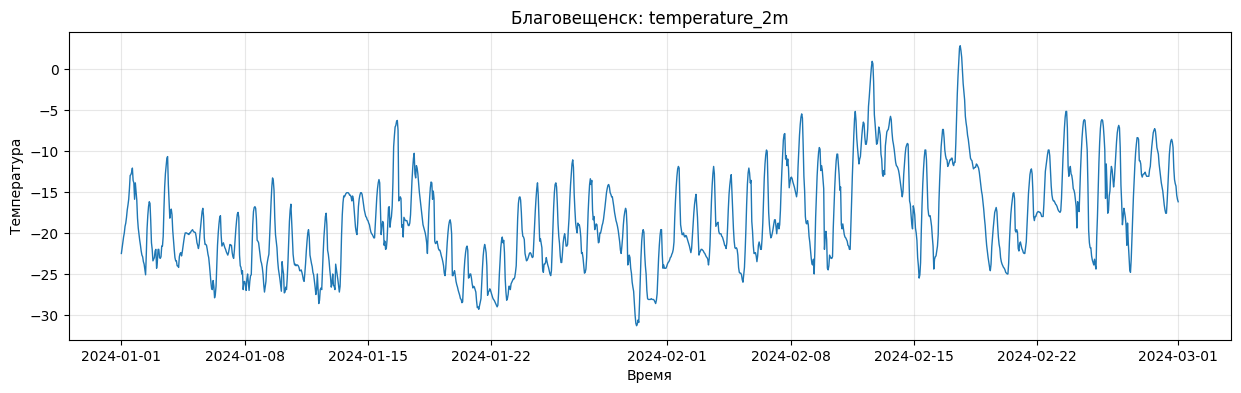

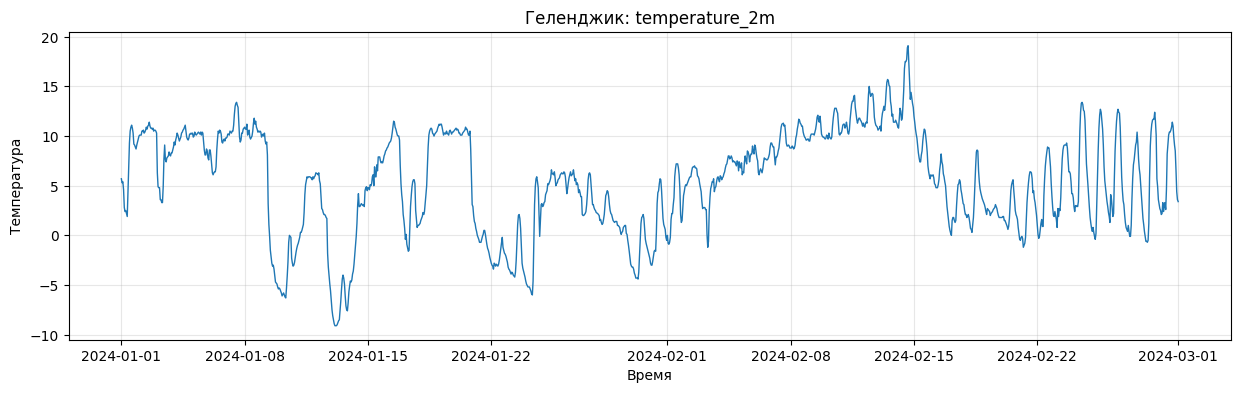

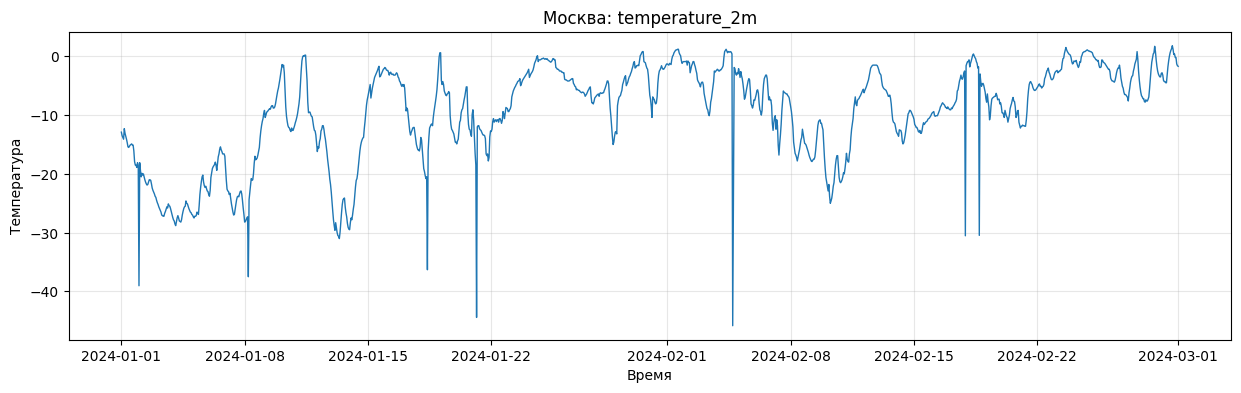

In [30]:
def plot_city_temperature(df, city, start=None, end=None, figsize=(15, 4)):
    tmp = df[df[CITY_COL] == city].copy()
    if start is not None:
        tmp = tmp[tmp[TIME_COL] >= pd.Timestamp(start)]
    if end is not None:
        tmp = tmp[tmp[TIME_COL] <= pd.Timestamp(end)]

    plt.figure(figsize=figsize)
    plt.plot(tmp[TIME_COL], tmp[TARGET_COL], linewidth=1)
    plt.title(f"{city}: {TARGET_COL}")
    plt.xlabel("Время")
    plt.ylabel("Температура")
    plt.grid(True, alpha=0.3)
    plt.show()

for city in sorted(final_df[CITY_COL].unique())[:3]:
    plot_city_temperature(final_df, city, start="2024-01-01", end="2024-03-01")

## 9. Проверка стационарности

ADF-тест корректнее интерпретировать на более сглаженном ряде.  
Ниже берём **дневное среднее** температуры по каждому городу, чтобы получить более читаемую диагностику.

In [32]:
daily_temp = (
    final_df.set_index(TIME_COL)
            .groupby(CITY_COL)[TARGET_COL]
            .resample("D")
            .mean()
            .reset_index()
)

adf_rows = []
for city, g in daily_temp.groupby(CITY_COL):
    s = g[TARGET_COL].dropna()
    stat, pvalue, lags, nobs, crit, icbest = adfuller(s, autolag="AIC")
    adf_rows.append({
        "city": city,
        "adf_stat": stat,
        "pvalue": pvalue,
        "nobs": nobs,
        "stationary_at_5pct": pvalue < 0.05
    })

adf_df = pd.DataFrame(adf_rows).sort_values("pvalue")
display(adf_df)

,city,adf_stat,pvalue,nobs,stationary_at_5pct
0,Благовещенск,-3.332597,0.013483,2531,True
4,Санкт-Петербург,-3.183392,0.020966,2542,True
2,Москва,-3.156156,0.022667,2541,True
1,Геленджик,-3.010906,0.033888,2539,True
5,Сочи,-3.007721,0.034180,2538,True
3,Находка,-2.979475,0.036856,2529,True


## Вывод:
По результатам ADF-теста для всех городов получены `p-value < 0.05`, поэтому гипотеза о нестационарности отвергается. Это означает, что дневные средние температуры в целом ведут себя как стационарные ряды. При этом вывод относится именно к сглаженному дневному ряду, а не к исходным почасовым данным

Обычно для погодных рядов чистая стационарность не выполняется: есть выраженная сезонность по году и по суткам

## 10. Декомпозиция: тренд, сезонность, остатки

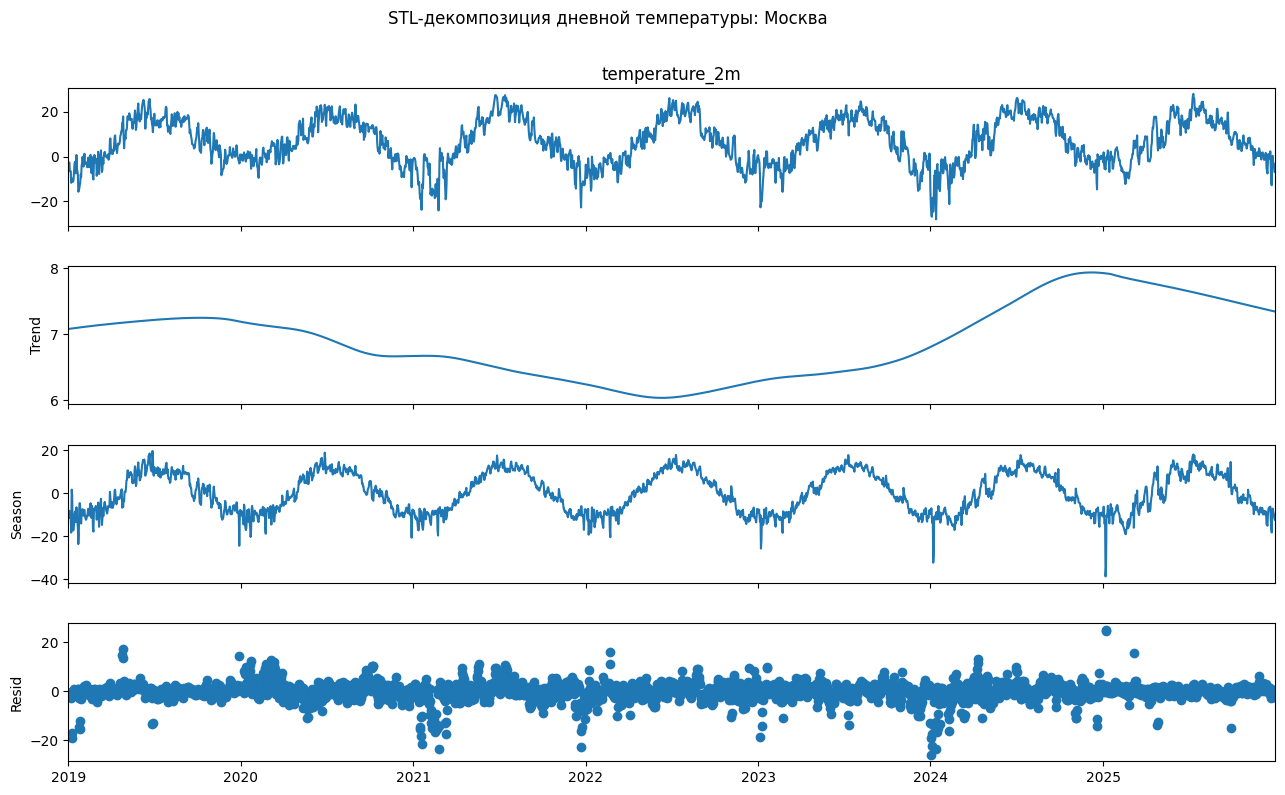

In [33]:
city_for_decomp = "Москва" if "Москва" in daily_temp[CITY_COL].unique() else daily_temp[CITY_COL].iloc[0]
s = (
    daily_temp[daily_temp[CITY_COL] == city_for_decomp]
    .set_index(TIME_COL)[TARGET_COL]
    .asfreq("D")
    .interpolate()
)

stl = STL(s, period=365, robust=True)
res = stl.fit()

fig = res.plot()
fig.set_size_inches(14, 8)
fig.suptitle(f"STL-декомпозиция дневной температуры: {city_for_decomp}", y=1.02)
plt.show()

## 11. Спектральный анализ

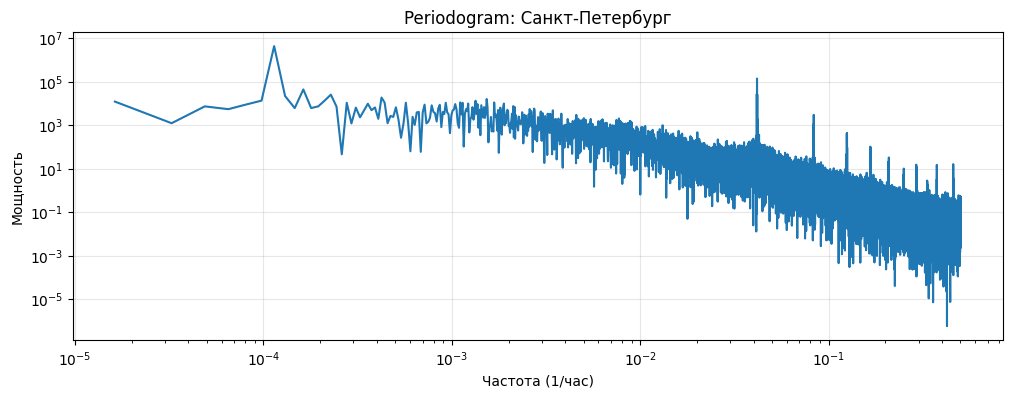

In [37]:
city_for_fft = "Санкт-Петербург" if "Санкт-Петербург" in final_df[CITY_COL].unique() else final_df[CITY_COL].iloc[0]
s_hourly = (
    final_df[final_df[CITY_COL] == city_for_fft]
    .set_index(TIME_COL)[TARGET_COL]
    .asfreq("h")
    .interpolate()
)

freqs, power = periodogram(s_hourly.values, fs=1.0)
mask = freqs > 0

plt.figure(figsize=(12, 4))
plt.plot(freqs[mask], power[mask])
plt.xscale("log")
plt.yscale("log")
plt.title(f"Periodogram: {city_for_fft}")
plt.xlabel("Частота (1/час)")
plt.ylabel("Мощность")
plt.grid(True, alpha=0.3)
plt.show()

## 12. Feature engineering

In [36]:
def add_calendar_features(df):
    df = df.copy()
    ts = pd.to_datetime(df[TIME_COL])

    df["hour"] = ts.dt.hour
    df["dayofweek"] = ts.dt.dayofweek
    df["dayofyear"] = ts.dt.dayofyear
    df["month"] = ts.dt.month
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

    # циклические признаки
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

    df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

    df["doy_sin"] = np.sin(2 * np.pi * df["dayofyear"] / 365.25)
    df["doy_cos"] = np.cos(2 * np.pi * df["dayofyear"] / 365.25)

    return df

feat_df = add_calendar_features(final_df)
display(feat_df.head())

,ds,city,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,...,dayofweek,dayofyear,month,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,doy_sin,doy_cos
0,2019-01-01 00:00:00,Благовещенск,-13.7,56.0,0.0,0.0,0.0,3.0,12.600000,1008.700012,...,1,1,1,0,0.000000,1.000000,0.781831,0.62349,0.017202,0.999852
1,2019-01-01 01:00:00,Благовещенск,-13.2,56.0,0.0,0.0,0.0,3.0,16.299999,1008.500000,...,1,1,1,0,0.258819,0.965926,0.781831,0.62349,0.017202,0.999852
2,2019-01-01 02:00:00,Благовещенск,-12.5,56.0,0.0,0.0,0.0,3.0,18.000000,1008.299988,...,1,1,1,0,0.500000,0.866025,0.781831,0.62349,0.017202,0.999852
3,2019-01-01 03:00:00,Благовещенск,-12.1,56.0,0.0,0.0,0.0,3.0,18.100000,1007.900024,...,1,1,1,0,0.707107,0.707107,0.781831,0.62349,0.017202,0.999852
4,2019-01-01 04:00:00,Благовещенск,-11.9,56.0,0.0,0.0,0.0,3.0,17.600000,1007.500000,...,1,1,1,0,0.866025,0.500000,0.781831,0.62349,0.017202,0.999852


In [39]:
def make_origin_level_features(city_df, origin_idx, window=WINDOW, horizon=HORIZON):
    hist = city_df.iloc[origin_idx - window:origin_idx].copy()
    origin_row = city_df.iloc[origin_idx].copy()

    feats = {}

    feats["city"] = origin_row[CITY_COL]
    feats["origin_time"] = origin_row[TIME_COL]

    lag_list = [1, 2, 3, 6, 12, 24, 48, 72, 96, 120, 144, 168]
    for lag in lag_list:
        feats[f"temp_lag_{lag}"] = hist[TARGET_COL].iloc[-lag]

    for w in [6, 12, 24, 48, 72, 168]:
        feats[f"temp_mean_{w}"] = hist[TARGET_COL].tail(w).mean()
        feats[f"temp_std_{w}"] = hist[TARGET_COL].tail(w).std()
        feats[f"temp_min_{w}"] = hist[TARGET_COL].tail(w).min()
        feats[f"temp_max_{w}"] = hist[TARGET_COL].tail(w).max()

    other_cols = [
        "relative_humidity_2m", "precipitation", "rain", "snowfall",
        "weathercode", "wind_speed_10m", "surface_pressure"
    ]
    for col in other_cols:
        feats[f"{col}_last"] = hist[col].iloc[-1]
        feats[f"{col}_mean_24"] = hist[col].tail(24).mean()
        feats[f"{col}_mean_72"] = hist[col].tail(72).mean()

    feats["hour"] = origin_row["hour"]
    feats["dayofweek"] = origin_row["dayofweek"]
    feats["month"] = origin_row["month"]
    feats["is_weekend"] = origin_row["is_weekend"]
    feats["hour_sin"] = origin_row["hour_sin"]
    feats["hour_cos"] = origin_row["hour_cos"]
    feats["dow_sin"] = origin_row["dow_sin"]
    feats["dow_cos"] = origin_row["dow_cos"]
    feats["doy_sin"] = origin_row["doy_sin"]
    feats["doy_cos"] = origin_row["doy_cos"]

    y_seq = city_df[TARGET_COL].iloc[origin_idx:origin_idx + horizon].values

    return feats, y_seq

def build_direct_dataset(df, window=WINDOW, horizon=HORIZON, origin_stride=ORIGIN_STRIDE):
    rows = []
    ys = []

    for city, g in df.groupby(CITY_COL):
        g = g.sort_values(TIME_COL).reset_index(drop=True)
        n = len(g)

        for origin_idx in range(window, n - horizon + 1, origin_stride):
            feats, y_seq = make_origin_level_features(g, origin_idx, window=window, horizon=horizon)
            rows.append(feats)
            ys.append(y_seq)

    X = pd.DataFrame(rows)
    Y = np.vstack(ys)
    return X, Y

X_direct, Y_direct = build_direct_dataset(feat_df)
print(X_direct.shape, Y_direct.shape)
display(X_direct.head())

(15264, 69) (15264, 168)


,city,origin_time,temp_lag_1,temp_lag_2,temp_lag_3,temp_lag_6,temp_lag_12,temp_lag_24,temp_lag_48,temp_lag_72,...,hour,dayofweek,month,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,doy_sin,doy_cos
0,Благовещенск,2019-01-08,-23.5,-25.200001,-24.500000,-22.0,-18.9,-21.000000,-19.100000,-23.600000,...,0,1,1,0,0.0,1.0,0.781831,0.623490,0.137185,0.990545
1,Благовещенск,2019-01-09,-19.9,-18.900000,-17.700001,-18.9,-14.8,-22.600000,-21.000000,-19.100000,...,0,2,1,0,0.0,1.0,0.974928,-0.222521,0.154204,0.988039
2,Благовещенск,2019-01-10,-15.3,-15.100000,-14.800000,-17.5,-10.8,-17.799999,-22.600000,-21.000000,...,0,3,1,0,0.0,1.0,0.433884,-0.900969,0.171177,0.985240
3,Благовещенск,2019-01-11,-17.4,-19.900000,-20.299999,-18.5,-12.1,-17.799999,-17.799999,-22.600000,...,0,4,1,0,0.0,1.0,-0.433884,-0.900969,0.188099,0.982150
4,Благовещенск,2019-01-12,-18.1,-19.500000,-18.000000,-13.9,-10.8,-17.299999,-17.799999,-17.799999,...,0,5,1,1,0.0,1.0,-0.974928,-0.222521,0.204966,0.978769


### Хронологическое разбиение train / val / test

Разделяем **по времени origin'ов**, без перемешивания.

In [40]:
unique_origins = np.sort(X_direct["origin_time"].unique())

n_origins = len(unique_origins)
train_end = unique_origins[int(n_origins * 0.70)]
val_end = unique_origins[int(n_origins * 0.85)]

print("train_end:", train_end)
print("val_end:", val_end)

train_mask = X_direct["origin_time"] < train_end
val_mask = (X_direct["origin_time"] >= train_end) & (X_direct["origin_time"] < val_end)
test_mask = X_direct["origin_time"] >= val_end

X_train_direct = X_direct.loc[train_mask].reset_index(drop=True)
Y_train_direct = Y_direct[train_mask.values]

X_val_direct = X_direct.loc[val_mask].reset_index(drop=True)
Y_val_direct = Y_direct[val_mask.values]

X_test_direct = X_direct.loc[test_mask].reset_index(drop=True)
Y_test_direct = Y_direct[test_mask.values]

print(X_train_direct.shape, Y_train_direct.shape)
print(X_val_direct.shape, Y_val_direct.shape)
print(X_test_direct.shape, Y_test_direct.shape)

train_end: 2023-11-23T00:00:00.000000000
val_end: 2024-12-09T00:00:00.000000000
(10680, 69) (10680, 168)
(2292, 69) (2292, 168)
(2292, 69) (2292, 168)


In [41]:
FEATURE_DROP_COLS = ["origin_time"]
CAT_COLS = ["city"]
NUM_COLS = [c for c in X_train_direct.columns if c not in CAT_COLS + FEATURE_DROP_COLS]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
        ]), NUM_COLS),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore")),
        ]), CAT_COLS),
    ],
    remainder="drop"
)

X_train_direct_pre = preprocessor.fit_transform(X_train_direct)
X_val_direct_pre = preprocessor.transform(X_val_direct)
X_test_direct_pre = preprocessor.transform(X_test_direct)

print(type(X_train_direct_pre), X_train_direct_pre.shape)

<class 'numpy.ndarray'> (10680, 73)
